# SMS Spam Classification using Machine Learning

This project applies supervised machine learning techniques to classify SMS messages as spam or not spam. The goal is to evaluate multiple models, compare their performance, and analyze their effectiveness on text classification tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("../data/spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Dataset 1: SMS Spam Classification

This dataset contains 5,572 SMS messages labeled as either spam or ham (not spam). The goal is to classify messages based on their content.

The dataset was selected because it is a well-known benchmark for text classification and has been widely used in prior machine learning research.

Preprocessing steps included:
- Selecting relevant columns
- Renaming columns for clarity
- Converting labels to numerical values
- Splitting data into training and testing sets

The dataset is slightly imbalanced, with more non-spam messages than spam messages.

In [3]:
df = df[["v1", "v2"]]
df.columns = ["label", "text"]

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
# Convert labels to numbers
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,text,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
X = df["text"]
y = df["label_num"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


## Model Development

Three supervised learning models were implemented:

- Logistic Regression: a linear model effective for text classification
- Naive Bayes: a probabilistic model commonly used for text data
- Decision Tree: a non-linear model that captures complex patterns

TF-IDF vectorization was used to convert text into numerical features.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

logreg_preds = logreg_pipeline.predict(X_test)

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, logreg_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



In [11]:
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)

nb_preds = nb_pipeline.predict(X_test)

In [12]:
print(classification_report(y_test, nb_preds))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



In [13]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

tree_preds = tree_pipeline.predict(X_test)

In [14]:
print(classification_report(y_test, tree_preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.88      0.85      0.87       149

    accuracy                           0.97      1115
   macro avg       0.93      0.92      0.92      1115
weighted avg       0.96      0.97      0.96      1115



In [15]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, logreg_preds),
        "Precision": precision_score(y_test, logreg_preds),
        "Recall": recall_score(y_test, logreg_preds),
        "F1 Score": f1_score(y_test, logreg_preds)
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, nb_preds),
        "Precision": precision_score(y_test, nb_preds),
        "Recall": recall_score(y_test, nb_preds),
        "F1 Score": f1_score(y_test, nb_preds)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, tree_preds),
        "Precision": precision_score(y_test, tree_preds),
        "Recall": recall_score(y_test, tree_preds),
        "F1 Score": f1_score(y_test, tree_preds)
    }
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974888,0.991870,0.818792,0.897059
1,Naive Bayes,0.964126,1.000000,0.731544,0.844961
2,Decision Tree,0.965022,0.881944,0.852349,0.866894


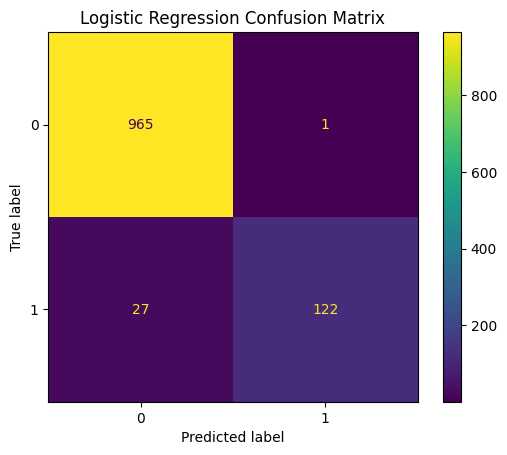

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, logreg_preds)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

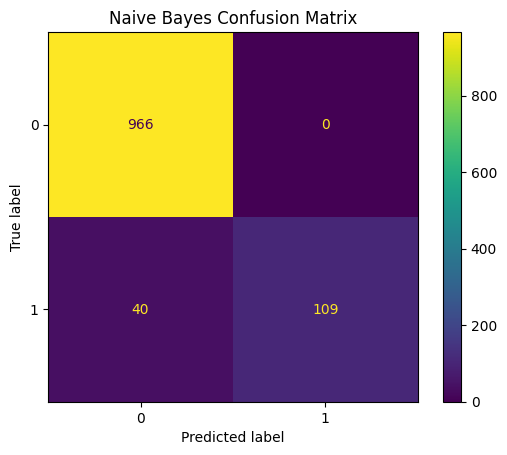

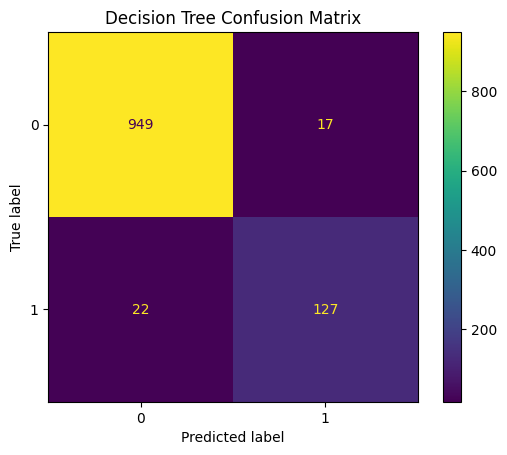

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_preds)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, tree_preds)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [18]:
param_grid = {
    "tfidf__max_features": [3000, 5000, 7000],
    "model__C": [0.1, 1, 10]
}

In [19]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    logreg_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'tfidf__max_features': [3000, 5000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

In [20]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__C': 10, 'tfidf__max_features': 3000}


In [21]:
best_model = grid_search.best_estimator_

tuned_preds = best_model.predict(X_test)

print(classification_report(y_test, tuned_preds))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## Hyperparameter Tuning

GridSearchCV was used to optimize the Logistic Regression model. The best parameters were:

- C = 10
- max_features = 3000

The tuned model improved performance, demonstrating the importance of hyperparameter optimization.

In [ ]:
df2 = pd.read_csv("../data/IMDB Dataset.csv")
df2.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Dataset 2: IMDB Sentiment Analysis

This dataset contains movie reviews labeled as positive or negative. The goal is to classify sentiment based on text.

This dataset was selected because it is a standard benchmark for natural language processing tasks and allows comparison across multiple models.

Preprocessing steps included:
- Renaming columns
- Converting sentiment labels to numerical values
- Splitting data into training and testing sets

In [23]:
df2.columns = ["text", "label"]
df2.head()

,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [24]:
df2.shape

(50000, 2)

In [25]:
df2["label"].value_counts()

label
positive    25000
negative    25000
Name: count, dtype: int64

In [26]:
df2["label_num"] = df2["label"].map({"negative": 0, "positive": 1})

In [27]:
X2 = df2["text"]
y2 = df2["label_num"]

In [28]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Train size:", len(X2_train))
print("Test size:", len(X2_test))

Train size: 40000
Test size: 10000


In [29]:
logreg_pipeline_2 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipeline_2.fit(X2_train, y2_train)

logreg_preds_2 = logreg_pipeline_2.predict(X2_test)

In [30]:
print(classification_report(y2_test, logreg_preds_2))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [31]:
nb_pipeline_2 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", MultinomialNB())
])

nb_pipeline_2.fit(X2_train, y2_train)

nb_preds_2 = nb_pipeline_2.predict(X2_test)

In [32]:
print(classification_report(y2_test, nb_preds_2))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85      5000
           1       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [33]:
tree_pipeline_2 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_pipeline_2.fit(X2_train, y2_train)

tree_preds_2 = tree_pipeline_2.predict(X2_test)

In [34]:
print(classification_report(y2_test, tree_preds_2))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      5000
           1       0.71      0.71      0.71      5000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



In [35]:
results_2 = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y2_test, logreg_preds_2),
        "Precision": precision_score(y2_test, logreg_preds_2),
        "Recall": recall_score(y2_test, logreg_preds_2),
        "F1 Score": f1_score(y2_test, logreg_preds_2)
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y2_test, nb_preds_2),
        "Precision": precision_score(y2_test, nb_preds_2),
        "Recall": recall_score(y2_test, nb_preds_2),
        "F1 Score": f1_score(y2_test, nb_preds_2)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y2_test, tree_preds_2),
        "Precision": precision_score(y2_test, tree_preds_2),
        "Recall": recall_score(y2_test, tree_preds_2),
        "F1 Score": f1_score(y2_test, tree_preds_2)
    }
])

results_2

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8931,0.889439,0.8978,0.893600
1,Naive Bayes,0.8555,0.853029,0.8590,0.856004
2,Decision Tree,0.7120,0.711324,0.7136,0.712460


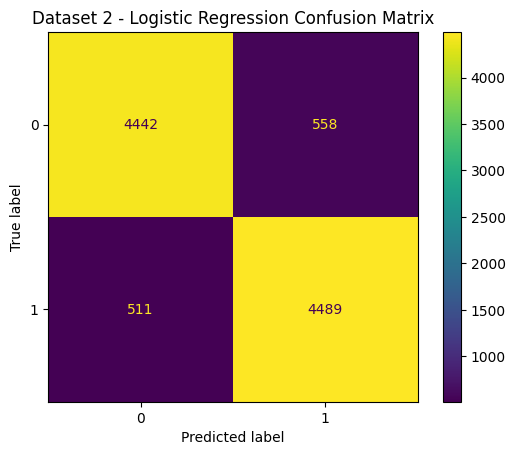

In [36]:
ConfusionMatrixDisplay.from_predictions(y2_test, logreg_preds_2)
plt.title("Dataset 2 - Logistic Regression Confusion Matrix")
plt.show()

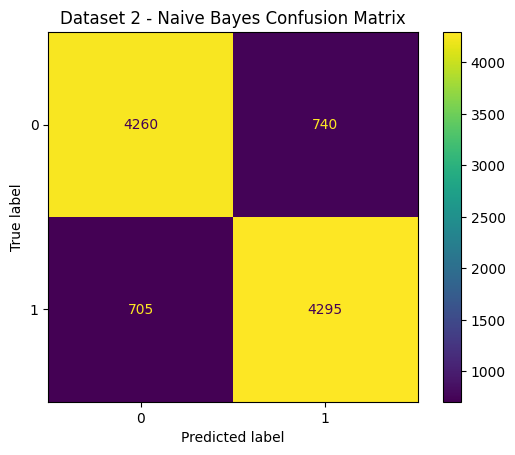

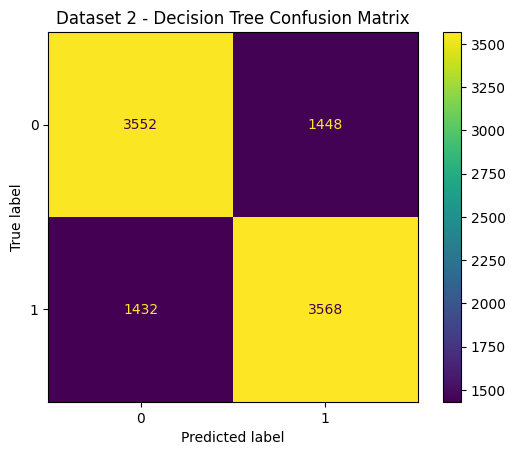

In [37]:
ConfusionMatrixDisplay.from_predictions(y2_test, nb_preds_2)
plt.title("Dataset 2 - Naive Bayes Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y2_test, tree_preds_2)
plt.title("Dataset 2 - Decision Tree Confusion Matrix")
plt.show()

In [38]:
comparison = pd.DataFrame([
    {
        "Dataset": "Spam",
        "Best Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, tuned_preds),
        "F1 Score": f1_score(y_test, tuned_preds)
    },
    {
        "Dataset": "IMDB",
        "Best Model": "Logistic Regression",
        "Accuracy": accuracy_score(y2_test, logreg_preds_2),
        "F1 Score": f1_score(y2_test, logreg_preds_2)
    }
])

comparison

,Dataset,Best Model,Accuracy,F1 Score
0,Spam,Logistic Regression,0.981166,0.925267
1,IMDB,Logistic Regression,0.893100,0.893600


In [39]:
results_2

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8931,0.889439,0.8978,0.893600
1,Naive Bayes,0.8555,0.853029,0.8590,0.856004
2,Decision Tree,0.7120,0.711324,0.7136,0.712460


In [40]:
comparison

,Dataset,Best Model,Accuracy,F1 Score
0,Spam,Logistic Regression,0.981166,0.925267
1,IMDB,Logistic Regression,0.893100,0.893600


## Results and Analysis

For the SMS Spam dataset, Logistic Regression achieved the highest performance with approximately 98% accuracy and the highest F1-score.

For the IMDB dataset, Logistic Regression also performed best, achieving approximately 89% accuracy.

Naive Bayes performed well but had lower recall in some cases, meaning it missed more positive classifications.

Decision Trees performed worse than the other models, likely due to overfitting and difficulty handling high-dimensional text data.

Overall, Logistic Regression was the most consistent and reliable model across both datasets.

## Reflection

This project demonstrated that classical machine learning models can perform effectively on text classification tasks when combined with TF-IDF feature extraction.

Logistic Regression consistently outperformed other models, showing strong generalization.

However, performance varied depending on dataset complexity, with the IMDB dataset being more challenging.

Future work could include using deep learning models such as neural networks or transformer-based models for improved performance.